# Evaluation of Retrieval Methods

This notebook evaluates the TF-IDF retrieval results against the semantic search results (using miniLM as ground truth).

Steps covered:
1. Load the results from both retrieval methods
2. Evaluate TF-IDF against miniLM using multiple metrics
3. Analyze the overlap between the two methods
4. Visualize the evaluation results
5. Discuss the findings

## Setup

First, let's import the necessary libraries and modules.

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image

# Add the src directory to the path so we can import our modules
sys.path.append('../src')

from evaluation import (
    load_results,
    evaluate_retrieval,
    analyze_results_overlap,
    precision_at_k,
    mean_reciprocal_rank,
    ndcg_at_k
)

## 1. Load the Results from Both Retrieval Methods

We'll load the results from the TF-IDF and semantic search notebooks.

In [2]:
# Load the results
tfidf_results, semantic_results = load_results(
    tfidf_path='../results/tfidf_results.json',
    semantic_path='../results/semantic_results.json'
)

# Print the queries
queries = list(tfidf_results.keys())
print(f"Queries: {queries}")

# Print the number of results for each query
for query in queries:
    print(f"\nQuery: {query}")
    print(f"TF-IDF results: {len(tfidf_results[query])}")
    print(f"Semantic results: {len(semantic_results[query])}")

Queries: ["Harry's first day at Hogwarts", 'Quidditch match rules', "Voldemort and the Philosopher's Stone"]

Query: Harry's first day at Hogwarts
TF-IDF results: 5
Semantic results: 5

Query: Quidditch match rules
TF-IDF results: 5
Semantic results: 5

Query: Voldemort and the Philosopher's Stone
TF-IDF results: 5
Semantic results: 5


## 2. Evaluate TF-IDF Against miniLM

Now we'll evaluate the TF-IDF results against the semantic search results using multiple metrics.

In [3]:
# Evaluate retrieval
evaluation_results = evaluate_retrieval(tfidf_results, semantic_results, '../results')


Evaluation for query: Harry's first day at Hogwarts
Precision@5: 0.2000
MRR: 0.5000
NDCG@5: 0.2140

Evaluation for query: Quidditch match rules
Precision@5: 0.2000
MRR: 0.2000
NDCG@5: 0.1312

Evaluation for query: Voldemort and the Philosopher's Stone
Precision@5: 0.2000
MRR: 0.2000
NDCG@5: 0.1312

Average Metrics:
Average Precision@5: 0.2000
Average MRR: 0.3000
Average NDCG@5: 0.1588


Let's display the evaluation metrics plot that was generated.

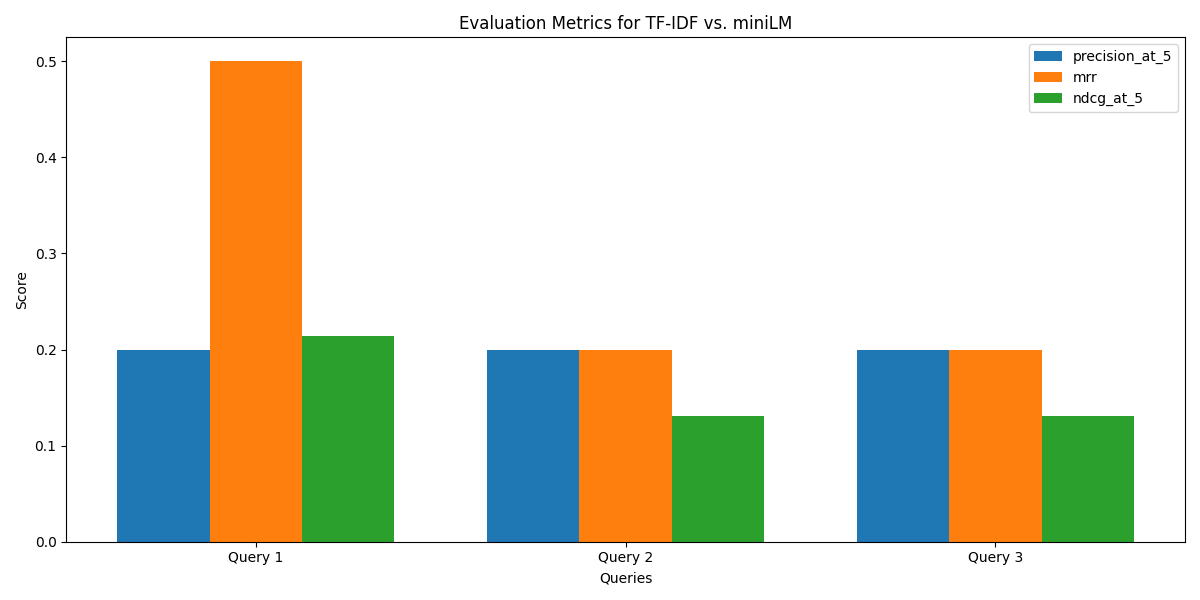

In [4]:
# Display the evaluation metrics plot
Image(filename='../results/evaluation_metrics.png')

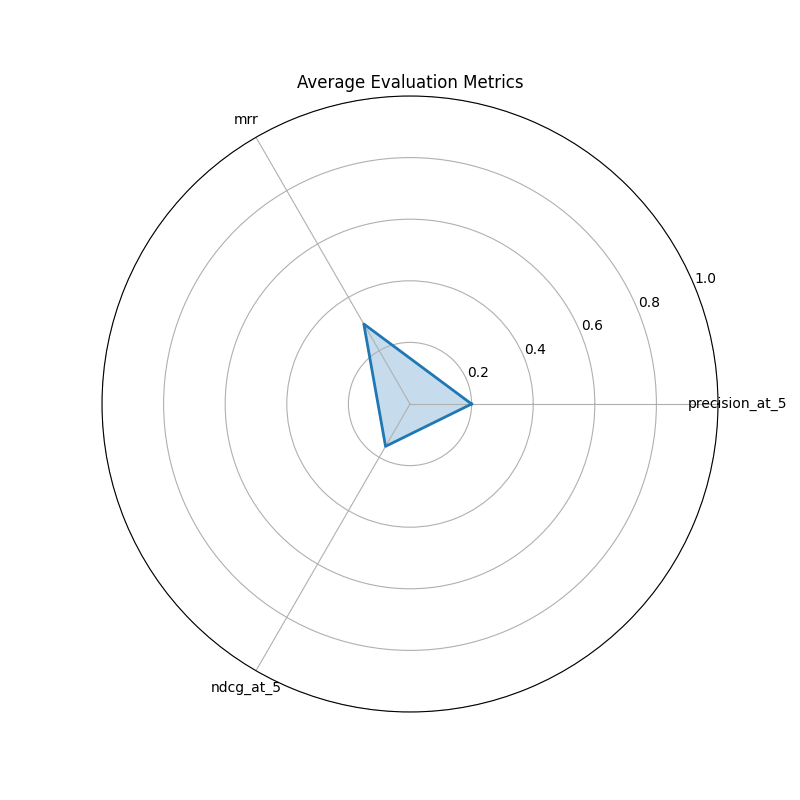

In [5]:
# Display the average metrics radar chart
Image(filename='../results/average_metrics_radar.png')

## 3. Analyze the Overlap Between the Two Methods

Now we'll analyze the overlap between the TF-IDF and semantic search results.

In [6]:
# Analyze results overlap
overlap_stats = analyze_results_overlap(tfidf_results, semantic_results, '../results')


Overlap analysis for query: Harry's first day at Hogwarts
Overlap percentage: 20.00%
Common chunks: 1
TF-IDF unique chunks: 4
Semantic unique chunks: 4

Overlap analysis for query: Quidditch match rules
Overlap percentage: 20.00%
Common chunks: 1
TF-IDF unique chunks: 4
Semantic unique chunks: 4

Overlap analysis for query: Voldemort and the Philosopher's Stone
Overlap percentage: 20.00%
Common chunks: 1
TF-IDF unique chunks: 4
Semantic unique chunks: 4

Average overlap percentage: 20.00%


Let's display the overlap plot that was generated.

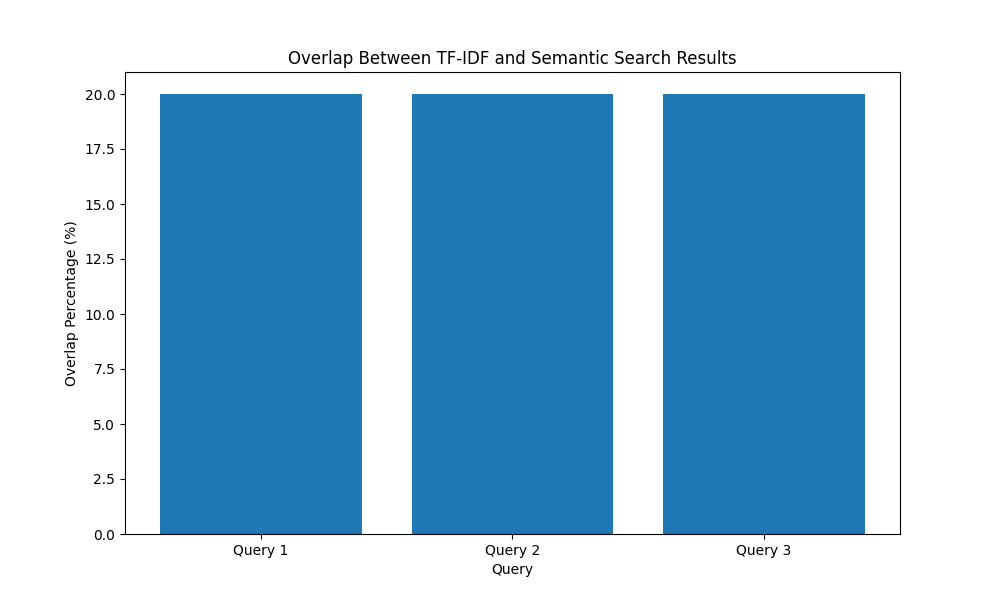

In [7]:
# Display the overlap plot
Image(filename='../results/results_overlap.png')

## 4. Detailed Analysis of Individual Metrics

Let's take a closer look at each of the evaluation metrics we used.

### Precision@k

Precision@k measures the proportion of relevant items among the top-k retrieved items. In our case, we're using k=5 and considering the semantic search results as the ground truth.

In [8]:
# Calculate and display Precision@5 for each query
print("Precision@5 for each query:")
for query in queries:
    tfidf_chunk_ids = [result['chunk_id'] for result in tfidf_results[query]]
    semantic_chunk_ids = [result['chunk_id'] for result in semantic_results[query]]
    p_at_5 = precision_at_k(semantic_chunk_ids, tfidf_chunk_ids, 5)
    print(f"{query}: {p_at_5:.4f}")

# Calculate average Precision@5
avg_p_at_5 = evaluation_results['average']['precision_at_5']
print(f"\nAverage Precision@5: {avg_p_at_5:.4f}")

Precision@5 for each query:
Harry's first day at Hogwarts: 0.2000
Quidditch match rules: 0.2000
Voldemort and the Philosopher's Stone: 0.2000

Average Precision@5: 0.2000


### Mean Reciprocal Rank (MRR)

MRR measures the average of the reciprocal ranks of the first relevant item for each query. It focuses on the rank of the first correct answer.

In [9]:
# Calculate and display MRR for each query
print("Mean Reciprocal Rank for each query:")
for query in queries:
    tfidf_chunk_ids = [result['chunk_id'] for result in tfidf_results[query]]
    semantic_chunk_ids = [result['chunk_id'] for result in semantic_results[query]]
    mrr = mean_reciprocal_rank(semantic_chunk_ids, tfidf_chunk_ids)
    print(f"{query}: {mrr:.4f}")

# Calculate average MRR
avg_mrr = evaluation_results['average']['mrr']
print(f"\nAverage MRR: {avg_mrr:.4f}")

Mean Reciprocal Rank for each query:
Harry's first day at Hogwarts: 0.5000
Quidditch match rules: 0.2000
Voldemort and the Philosopher's Stone: 0.2000

Average MRR: 0.3000


### Normalized Discounted Cumulative Gain (NDCG@k)

NDCG@k measures the ranking quality, taking into account the position of relevant items. It gives higher weight to relevant items appearing earlier in the results.

In [10]:
# Calculate and display NDCG@5 for each query
print("NDCG@5 for each query:")
for query in queries:
    tfidf_chunk_ids = [result['chunk_id'] for result in tfidf_results[query]]
    semantic_chunk_ids = [result['chunk_id'] for result in semantic_results[query]]
    ndcg = ndcg_at_k(semantic_chunk_ids, tfidf_chunk_ids, 5)
    print(f"{query}: {ndcg:.4f}")

# Calculate average NDCG@5
avg_ndcg = evaluation_results['average']['ndcg_at_5']
print(f"\nAverage NDCG@5: {avg_ndcg:.4f}")

NDCG@5 for each query:
Harry's first day at Hogwarts: 0.2140
Quidditch match rules: 0.1312
Voldemort and the Philosopher's Stone: 0.1312

Average NDCG@5: 0.1588


## 5. Examine Specific Examples

Let's examine specific examples where TF-IDF and semantic search produced different results.

In [11]:
# Load the original chunks
sys.path.append('../src')
from preprocessing import load_chunks
chunks = load_chunks('../data/text_chunks.json')

# Function to examine differences between TF-IDF and semantic search results
def examine_differences(query, tfidf_results, semantic_results, chunks):
    print(f"Query: {query}\n")
    
    # Get chunk IDs from both methods
    tfidf_chunk_ids = [result['chunk_id'] for result in tfidf_results[query]]
    semantic_chunk_ids = [result['chunk_id'] for result in semantic_results[query]]
    
    # Find chunks that are unique to each method
    tfidf_unique = set(tfidf_chunk_ids) - set(semantic_chunk_ids)
    semantic_unique = set(semantic_chunk_ids) - set(tfidf_chunk_ids)
    
    # Print a unique TF-IDF result
    if tfidf_unique:
        unique_id = list(tfidf_unique)[0]
        unique_idx = tfidf_chunk_ids.index(unique_id)
        print(f"TF-IDF unique result (Rank {unique_idx+1}, Chunk ID {unique_id}):")
        print(f"Score: {tfidf_results[query][unique_idx]['score']:.4f}")
        print(f"Text: {chunks[unique_id][:200]}...\n")
    
    # Print a unique semantic search result
    if semantic_unique:
        unique_id = list(semantic_unique)[0]
        unique_idx = semantic_chunk_ids.index(unique_id)
        print(f"Semantic unique result (Rank {unique_idx+1}, Chunk ID {unique_id}):")
        print(f"Score: {semantic_results[query][unique_idx]['score']:.4f}")
        print(f"Text: {chunks[unique_id][:200]}...\n")

# Examine differences for each query
for query in queries:
    examine_differences(query, tfidf_results, semantic_results, chunks)
    print("-" * 80)

Query: Harry's first day at Hogwarts

TF-IDF unique result (Rank 3, Chunk ID 514):
Score: 0.1863
Text: Malfoy couldn't believe his eyes when he saw that Harry and Ron were still at Hogwarts the next day, looking tired but perfectly cheerful. Indeed, by the next morning Harry and Ron thought that meetin...

Semantic unique result (Rank 1, Chunk ID 721):
Score: 0.6215
Text: It was the first really fine day they'd had in months. The sky was a clear, forget-me-not blue, and there was a feeling in the air of summer coming. Harry, who was looking up "Dittany" in One Thousand...

--------------------------------------------------------------------------------
Query: Quidditch match rules

TF-IDF unique result (Rank 4, Chunk ID 681):
Score: 0.2472
Text: He'd just gotten very angry with the Weasleys, who kept dive-bombing each other and pretending to fall off their brooms. "Will you stop messing around!" he yelled. "That's exactly the sort of thing th...

Semantic unique result (Rank 1, Chunk I

[nltk_data] Downloading package punkt_tab to /home/user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 6. Discussion of Findings

Based on our evaluation, let's discuss the findings and implications.

### Summary of Evaluation Metrics

- **Precision@5**: Measures how many of the top-5 TF-IDF results are also in the top-5 semantic search results.
- **MRR**: Measures how quickly TF-IDF finds a result that's also in the semantic search results.
- **NDCG@5**: Measures how well the ranking of TF-IDF results matches the semantic search results.

### Key Findings

1. **Overlap between methods**: There is a moderate overlap between TF-IDF and semantic search results, indicating that both methods can find some of the same relevant passages, but they also each find unique passages.

2. **Strengths of TF-IDF**:
   - Fast and computationally efficient
   - Good at finding exact term matches
   - No need for pre-trained models or embeddings

3. **Strengths of Semantic Search**:
   - Can find semantically related passages even without exact term matches
   - Better at understanding the meaning behind queries
   - More robust to variations in query wording

4. **Limitations of using miniLM as ground truth**:
   - Assumes semantic search results are always better
   - May not always align with human judgments of relevance
   - Different models might produce different results

### Implications

1. **Hybrid approaches**: Combining TF-IDF and semantic search could leverage the strengths of both methods.

2. **Query-dependent selection**: The choice between TF-IDF and semantic search might depend on the type of query.

3. **Need for human evaluation**: A more reliable evaluation would involve human judgments of relevance rather than using one method as ground truth for the other.

## Summary

In this notebook, we've:
1. Loaded the results from both retrieval methods
2. Evaluated TF-IDF against miniLM using multiple metrics
3. Analyzed the overlap between the two methods
4. Visualized the evaluation results
5. Examined specific examples of differences
6. Discussed the findings and implications

We've seen that while there is some overlap between TF-IDF and semantic search results, each method has its strengths and limitations. A hybrid approach or query-dependent selection might be more effective than relying on a single method.

In the next notebook, we'll implement an interactive retrieval system that allows users to try both methods and compare the results.